<a href="https://colab.research.google.com/github/Syed07Asif/Syed07Asif-Brain_tumor_Classification-DEEPLEARNING/blob/main/Brain_tumor_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!nvidia-smi
!pip install torch torchvision torchaudio timm matplotlib scikit-learn opencv-python grad-cam


Sat Oct 18 09:52:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             32W /   70W |    2170MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [40]:
from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

In [ ]:
import zipfile
import os

zip_path = "/content/brain_tumor_classification.zip"
extract_path = "/content/brain_tumor_classification"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")
os.listdir(extract_path)


In [41]:
import os
import cv2
import numpy as np
from tqdm import tqdm

train_dir = "/content/brain_tumor_classification/Training"
test_dir = "/content/brain_tumor_classification/Testing"

# Classes
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Image size
IMG_SIZE = 128

def load_data(data_dir):
    data = []
    for category in categories:
        path = os.path.join(data_dir, category)
        label = categories.index(category)
        for img_name in tqdm(os.listdir(path), desc=f"Loading {category}"):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append([img, label])
            except Exception as e:
                pass
    return np.array(data, dtype=object)

# Load training and testing data
train_data = load_data(train_dir)
test_data = load_data(test_dir)

print(f" Training samples: {len(train_data)}")
print(f" Testing samples: {len(test_data)}")


Loading pituitary_tumor: 100%|██████████| 74/74 [00:00<00:00, 369.66it/s]

✅ Training samples: 2870
✅ Testing samples: 394


In [42]:
# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import os
import numpy as np
import matplotlib.pyplot as plt


In [43]:
dataset_path = "/content/brain_tumor_classification"
img_height, img_width = 224, 224
batch_size = 32


In [44]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 2612 images belonging to 2 classes.
Found 652 images belonging to 2 classes.


In [45]:
num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,114 (42.61 MB)

 Trainable params: 11,169,666 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [46]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_brain_tumor_model.h5", save_best_only=True)
]


In [47]:
epochs = 35

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=callbacks
)


Epoch 1/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8255 - loss: 0.9859

82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 574ms/step - accuracy: 0.8258 - loss: 0.9822 - val_accuracy: 0.7255 - val_loss: 0.6496
Epoch 2/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8690 - loss: 0.4062

82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 504ms/step - accuracy: 0.8690 - loss: 0.4059 - val_accuracy: 0.8804 - val_loss: 0.3410
Epoch 3/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.8788 - loss: 0.3587

82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 516ms/step - accuracy: 0.8788 - loss: 0.3587 - val_accuracy: 0.8896 - val_loss: 0.3167
Epoch 4/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 500ms/step - accuracy: 0.8832 - loss: 0.3580 - val_accuracy: 0.8804 - val_loss: 0.4708
Epoch 5/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 495ms/step - accuracy: 0.8810 - loss: 0.3019 - val_accuracy: 0.8834 - val_loss: 0.3216
Epoch 6/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8745 - loss: 0.3361

82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 511ms/step - accuracy: 0.8746 - loss: 0.3359 - val_accuracy: 0.8880 - val_loss: 0.2846
Epoch 7/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8737 - loss: 0.3330

82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 499ms/step - accuracy: 0.8737 - loss: 0.3328 - val_accuracy: 0.8819 - val_loss: 0.2676
Epoch 8/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8881 - loss: 0.2943

82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 516ms/step - accuracy: 0.8880 - loss: 0.2945 - val_accuracy: 0.8865 - val_loss: 0.2326
Epoch 9/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 508ms/step - accuracy: 0.8900 - loss: 0.2968 - val_accuracy: 0.8804 - val_loss: 0.3135
Epoch 10/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 506ms/step - accuracy: 0.8793 - loss: 0.3170 - val_accuracy: 0.8850 - val_loss: 0.2671
Epoch 11/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 501ms/step - accuracy: 0.8822 - loss: 0.3029 - val_accuracy: 0.8850 - val_loss: 0.2477
Epoch 12/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 499ms/step - accuracy: 0.8725 - loss: 0.3177 - val_accuracy: 0.8819 - val_loss: 0.2680
Epoch 13/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 502ms/step - accuracy: 0.8717 - loss: 0.3094 - val_accuracy: 0.8834 - val_loss: 0.2620


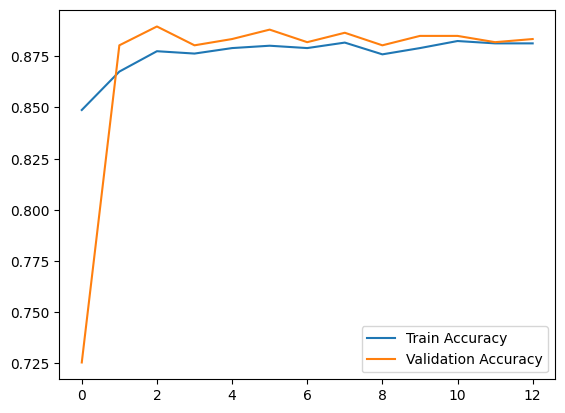

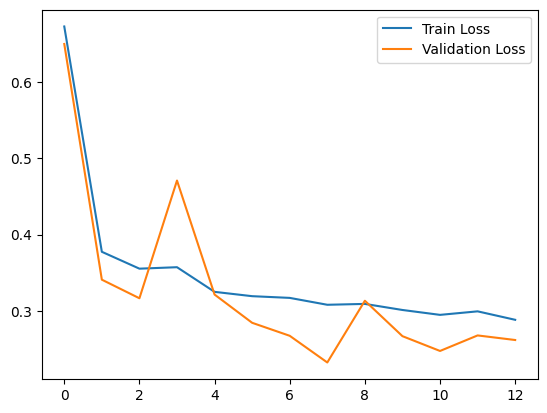

In [48]:
# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Plot training vs validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


Saving test_image.jpg to test_image.jpg

✅ Image uploaded: test_image.jpg
Detected class labels: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🧠 Predicted class: meningioma_tumor
📊 Confidence: 66.03%


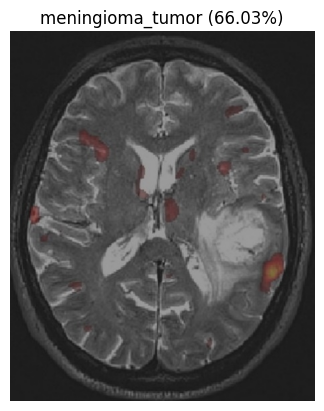

In [50]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()

for filename in uploaded.keys():
    img_path = '/content/' + filename
    print(f"\n✅ Image uploaded: {filename}")

dataset_path = "/content/brain_tumor_classification/Training"

class_labels = sorted(os.listdir(dataset_path))
print("Detected class labels:", class_labels)

img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

pred = model.predict(img_array)
class_idx = np.argmax(pred)
confidence = np.max(pred)

predicted_label = class_labels[class_idx]
print(f"\n🧠 Predicted class: {predicted_label}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.imshow(image.load_img(img_path))
plt.title(f"{predicted_label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()



In [54]:
%cd /content/brain_tumor_classification

!git init

!git config --global user.email "asiffisa07@gmail.com"
!git config --global user.name "Syed07Asif"

!git add .

!git commit -m "Initial commit: Brain Tumor Classification project"

!git remote add origin https://github.com/Syed07Asif/Brain_tumor_Classification-DEEPLEARNING.git

!git branch -M main
!git push -u origin main

/content/brain_tumor_classification
Reinitialized existing Git repository in /content/brain_tumor_classification/.git/
On branch main
nothing to commit, working tree clean
error: remote origin already exists.
fatal: could not read Username for 'https://github.com': No such device or address
